## Моделирование VaR портфеля
1. Работа с временными рядами
2. Различные подходы
   - Произведение одномерных распределений
   - Многомерные распределения
   - Копулы
3. Бектестирование
   - Тест Купика

In [2]:
# Раскомментировать, если не установлены 
!pip install arch
!pip install copulae
# # https://copulae.readthedocs.io/en/latest/getting-started.html


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached copulae-0.8.0.tar.gz (803 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached wrapt-1.17.3-cp314-cp314-win_amd64.whl.metadata (6.5 kB)
Using cached wrapt-1.17.3-cp314-cp314-win_amd64.whl (39 kB)
Failed to build copulae


  error: subprocess-exited-with-error
  
  × Building wheel for copulae (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [230 lines of output]
      C:\Users\РђРЅР°СЃС‚Р°СЃРёСЏ\AppData\Local\Temp\pip-build-env-fidbignm\overlay\Lib\site-packages\setuptools\config\_apply_pyprojecttoml.py:82: SetuptoolsDeprecationWarning: `project.license` as a TOML table is deprecated
      !!
      
              ********************************************************************************
              Please use a simple string containing a SPDX expression for `project.license`. You can also use `project.license-files`. (Both options available on setuptools>=77.0.0).
      
              By 2027-Feb-18, you need to update your project and remove deprecated calls
              or your builds will no longer be supported.
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              ***********************************

In [3]:
import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns

from arch import arch_model 

plt.style.use("bmh")
%config InlineBackend.figure_formats=["png"]

## Данные

In [4]:
prices = pd.read_csv('dataset.csv')
prices = prices.set_index('datetime')

prices.head()

,GAZP,SBER,LKOH,ROSN
datetime,,,,
2016-03-11,144.30,109.26,2669.0,301.60
2016-03-14,143.20,109.26,2658.5,301.05
2016-03-15,142.54,106.46,2647.5,300.60
2016-03-16,144.75,107.00,2703.0,301.25
2016-03-17,147.27,109.47,2750.0,309.40


Строим график цен

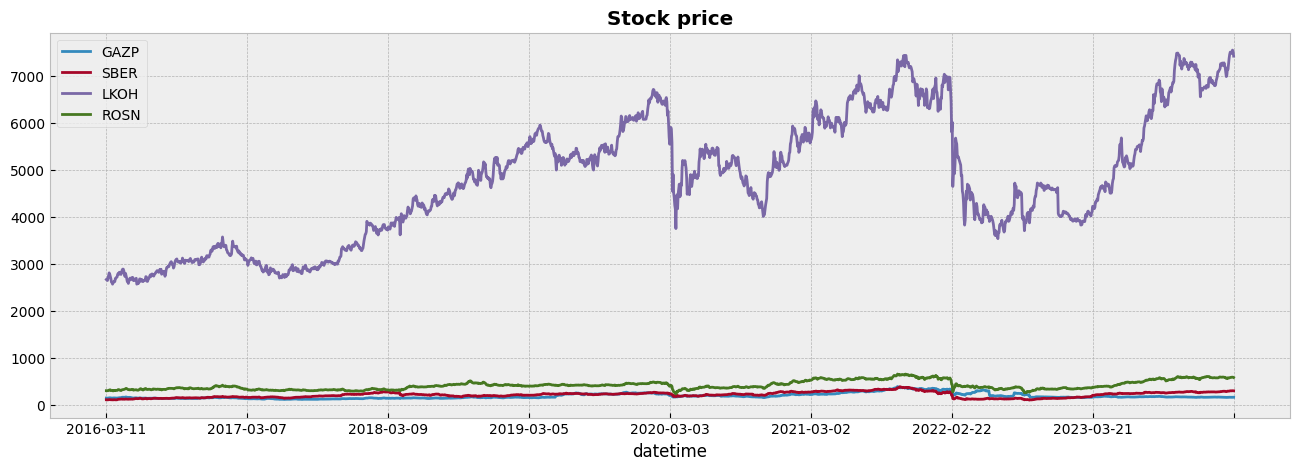

In [5]:
prices.plot(figsize=(16, 5))
plt.title("Stock price", weight="bold")
plt.show()

Строим графики доходностей

In [6]:
returns = 100*prices.pct_change().dropna()

returns.head()

,GAZP,SBER,LKOH,ROSN
datetime,,,,
2016-03-14,-0.762301,0.000000,-0.393406,-0.182361
2016-03-15,-0.460894,-2.562694,-0.413767,-0.149477
2016-03-16,1.550442,0.507233,2.096317,0.216234
2016-03-17,1.740933,2.308411,1.738809,2.705394
2016-03-18,2.295104,2.676532,2.181818,1.987718


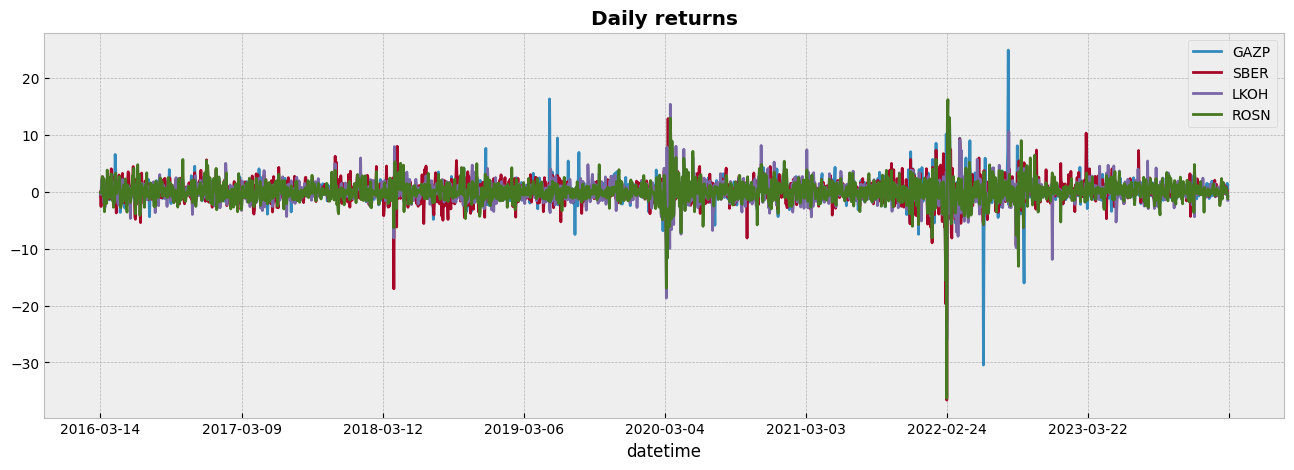

In [7]:
returns.plot(figsize=(16, 5))
plt.title("Daily returns", weight="bold")
plt.show()

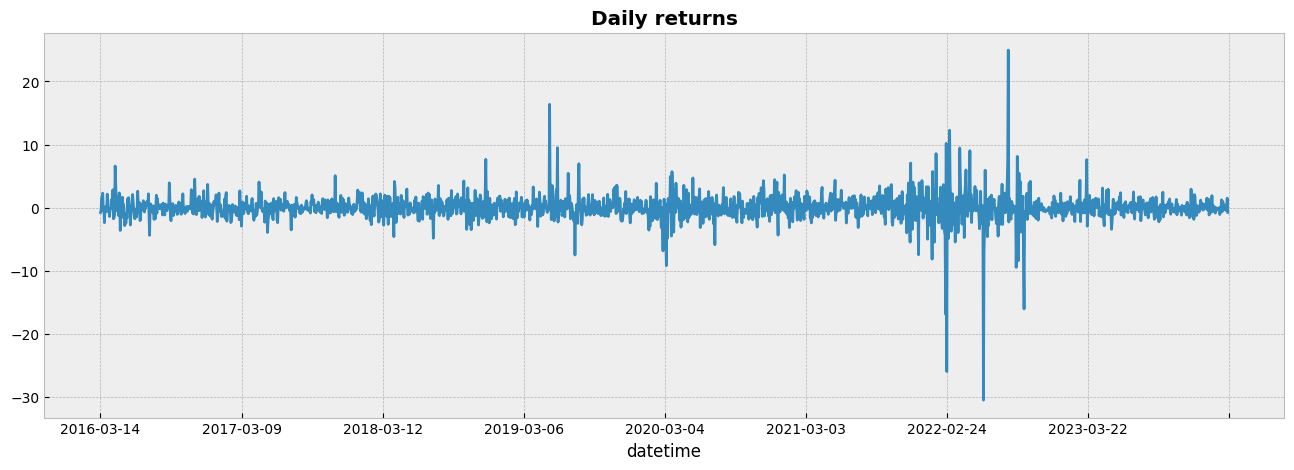

In [8]:
ret = returns['GAZP']

ret.plot(figsize=(16, 5))
plt.title("Daily returns", weight="bold")
plt.show()

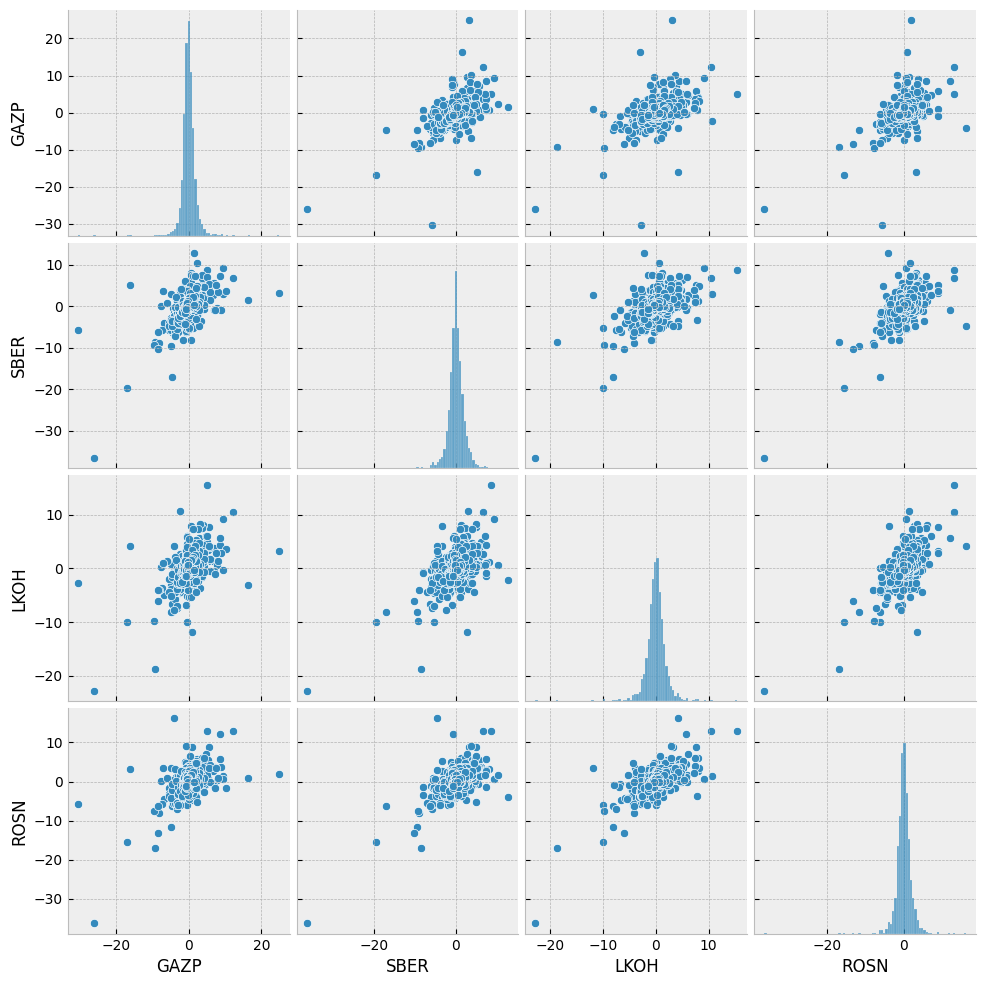

In [9]:
sns.pairplot(returns)

plt.show()

Возьмем функции для моделирования VaR различными способами с предыдущего семинара

In [10]:
def calculate_var_HS(returns, alpha):
    
    return returns.quantile(alpha)


def calculate_var_gennorm(returns, alpha):
    beta, loc, scale = scipy.stats.gennorm.fit(returns)
    
    return scipy.stats.gennorm.ppf(alpha, beta, loc, scale)


def calculate_var_garch(returns, alpha):
    
    scaling_const = 10.0 / returns.std()

    dist = 'skewstudent'
    am = arch_model(scaling_const * returns,
                    mean='HARX', lags=1, # mean = Constant, ARX, HARX + the number of lags
                    vol='Garch', p=1, o=1, q=1, # vol = Garch, EGARCH, HARCH + the number of lags
                    dist=dist) # dist = Normal, t, skewstudent, ged

    res = am.fit(update_freq=0, disp='off')

    forecasts = res.forecast(horizon=1, reindex=False)

    cond_mean = float(forecasts.mean.iloc[-1])
    cond_var = float(forecasts.variance.iloc[-1])

    if dist == 'Normal':
        q = am.distribution.ppf(alpha)
    elif dist == 't' or dist == 'ged':
        q = am.distribution.ppf(alpha, res.params[-1:])
    elif dist == 'skewstudent':
        q = am.distribution.ppf(alpha, res.params[-2:])

    return_garch_forecast = cond_mean / scaling_const
    VaR_garch_forecast = (cond_mean + np.sqrt(cond_var) * q) / scaling_const

    return return_garch_forecast, VaR_garch_forecast

In [11]:
ret = returns['GAZP']

returns.columns

Index(['GAZP', 'SBER', 'LKOH', 'ROSN'], dtype='object')

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [12]:
alpha = 0.01

T = len(ret)
T_start = 100
estimation_window = 250
testing_window = T - estimation_window

VaR_curve_HS = []
VaR_curve_gennorm = []
VaR_curve_garch = []
forecast_garch = []

for t in range(estimation_window+T_start, T):
    
    current_estimation_sample = ret[t-estimation_window:t]

    VaR_curve_HS.append(calculate_var_HS(current_estimation_sample, alpha))
    VaR_curve_gennorm.append(calculate_var_gennorm(current_estimation_sample, alpha))
    
    return_garch_forecast, VaR_garch_forecast = calculate_var_garch(current_estimation_sample, alpha)
    forecast_garch.append(return_garch_forecast)
    VaR_curve_garch.append(VaR_garch_forecast)
    
VaR_curve_HS = pd.Series(VaR_curve_HS, index=ret[estimation_window+T_start:].index)
VaR_curve_gennorm = pd.Series(VaR_curve_gennorm, index=ret[estimation_window+T_start:].index)
VaR_curve_garch = pd.Series(VaR_curve_garch, index=ret[estimation_window+T_start:].index)
forecast_garch = pd.Series(forecast_garch, index=ret[estimation_window+T_start:].index)

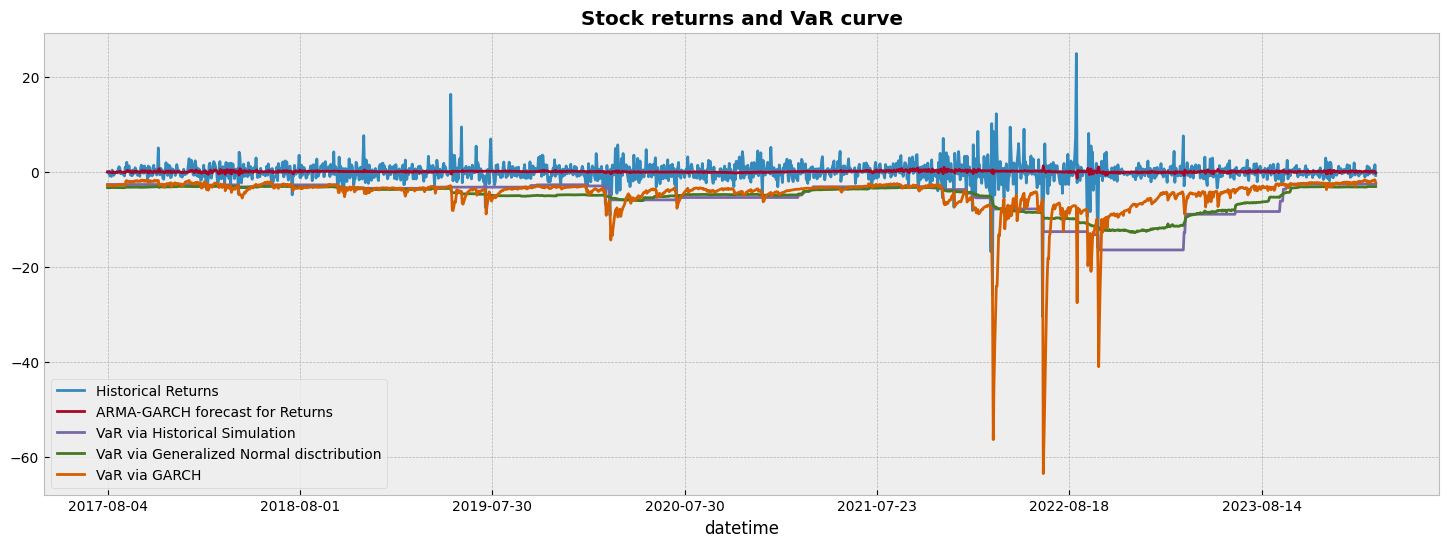

In [11]:
fig = plt.figure()
fig.set_size_inches(18,6)
ret[estimation_window+T_start:].plot()
forecast_garch.plot()
VaR_curve_HS.plot()
VaR_curve_gennorm.plot()
VaR_curve_garch.plot()

plt.title("Stock returns and VaR curve", weight="bold")

plt.legend(['Historical Returns',
            'ARMA-GARCH forecast for Returns',
            'VaR via Historical Simulation',
            'VaR via Generalized Normal disctribution',
           'VaR via GARCH'])
plt.show()

Таким образом, мы для каждого способа моделирования получили кривую VaR

Вопросы:
- Какой способ подсчета VaR выбрать? 
- Как моделировать доходность портфеля из нескольких активов?

Для выбора подходящей модели будем использовать тест Купика, который сравнивает модельную и реальную частоту пробоев.

[Overview of VaR Backtesting](https://www.mathworks.com/help/risk/overview-of-var-backtesting.html)

In [12]:
def kupiec_test(VaR_curve, actual_returns, pp=0.1):
    
    T = len(actual_returns)
    K = (actual_returns < VaR_curve).sum()
    alpha_0 = K / T
    
    S = -2*np.log((1-alpha)**(T-K) * alpha**K) + 2*np.log((1-alpha_0)**(T-K) * alpha_0**K)
    p_value = 1 - scipy.stats.chi2.cdf(S, df=1)
        
    if np.isnan(p_value):
        p_value = 0.
        
    print('Количество наблюдений:', T)
    print('Желаемый уровень пробитий: {:.1f}%'.format(alpha*100))
    print('Уровень пробитий в модели: {:.2f}%'.format(alpha_0*100))
        
    print('\np-value теста: {:.3f}'.format(p_value))
    if p_value > pp:
        print("""\nПри уровне значимости {:.0f}% гипотеза гипотеза о
том, что эмпирическая и модельная частоты превышений фактическими
убытками границы VaR равны, НЕ ОТВЕРГАЕТСЯ""".format(pp*100))
    else:
        print("""\nПри уровне значимости {:.1f}% гипотеза гипотеза о
том, что эмпирическая и модельная частоты превышений фактическими
убытками границы VaR равны, отвергается""".format(pp*100))

In [13]:
kupiec_test(VaR_curve_gennorm, ret[estimation_window+T_start:])

Количество наблюдений: 1649
Желаемый уровень пробитий: 1.0%
Уровень пробитий в модели: 1.09%

p-value теста: 0.713

При уровне значимости 10% гипотеза гипотеза о
том, что эмпирическая и модельная частоты превышений фактическими
убытками границы VaR равны, НЕ ОТВЕРГАЕТСЯ


In [14]:
kupiec_test(VaR_curve_garch, ret[estimation_window+T_start:])

Количество наблюдений: 1649
Желаемый уровень пробитий: 1.0%
Уровень пробитий в модели: 1.21%

p-value теста: 0.401

При уровне значимости 10% гипотеза гипотеза о
том, что эмпирическая и модельная частоты превышений фактическими
убытками границы VaR равны, НЕ ОТВЕРГАЕТСЯ


--------
Теперь будем моделировать совместное распределение длходностей активов, чтобы подсчитать Value-at-Risk всего портфеля.

Сначала посмотрим на историческое распределение доходностей двух акций

<Figure size 600x600 with 0 Axes>

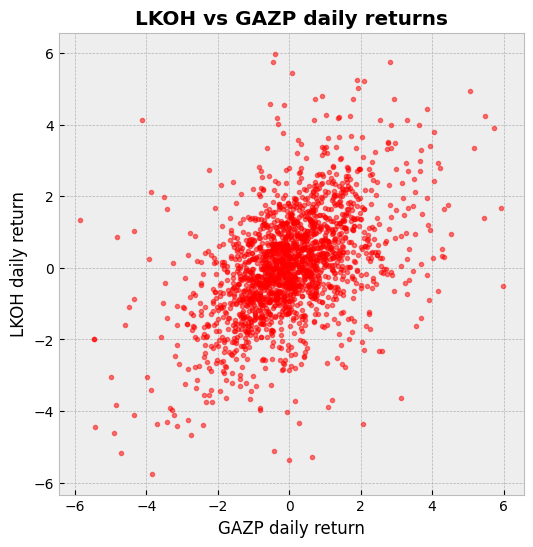

In [15]:
idx = (returns['GAZP'] > -6) & (returns['GAZP'] < 6)
idx = idx & (returns['LKOH'] > -6) & (returns['LKOH'] < 6)

x = returns.loc[idx, 'GAZP']
y = returns.loc[idx, 'LKOH']

fig = plt.figure()
fig.set_size_inches(6,6)

fig = plt.figure()
fig.set_size_inches(6,6)

plt.plot(x, y, "r.", alpha=0.5)
plt.xlabel("GAZP daily return")
plt.ylabel("LKOH daily return")
plt.title("LKOH vs GAZP daily returns", weight="bold")
plt.show()

Мы можем смоделировать частные распределения с помощью уже известных нам распределений, например Стьюдента

In [16]:
n_samples = 10 ** 5

return_simulations = {}

# для каждой акции оцениваем одномерное распределение, а потом сэмплируем из него новые псевдо-наблюдения
for col in returns.columns:
    t_df, t_mean, t_sigma = scipy.stats.t.fit(returns[col])
    return_simulations[col] = scipy.stats.t.rvs(t_df, loc=t_mean, scale=t_sigma, size=n_samples, random_state=42)
    
return_simulations = pd.DataFrame(return_simulations)

In [17]:
return_simulations.head()

,GAZP,SBER,LKOH,ROSN
0,0.625613,0.842200,0.759224,0.753370
1,-1.174951,-1.275326,-1.172595,-1.262573
2,1.341635,1.706683,1.557612,1.599240
3,-0.952994,-0.990456,-0.902619,-0.967872
4,1.292863,1.461224,1.262334,1.205767


In [18]:
returns.head()

,GAZP,SBER,LKOH,ROSN
datetime,,,,
2016-03-14,-0.762301,0.000000,-0.393406,-0.182361
2016-03-15,-0.460894,-2.562694,-0.413767,-0.149477
2016-03-16,1.550442,0.507233,2.096317,0.216234
2016-03-17,1.740933,2.308411,1.738809,2.705394
2016-03-18,2.295104,2.676532,2.181818,1.987718


In [19]:
np.cov(returns.values, rowvar=False)

array([[4.45711415, 2.56512179, 2.07652056, 2.40037646],
       [2.56512179, 4.74933676, 2.30557662, 2.71789133],
       [2.07652056, 2.30557662, 3.72401534, 2.69157976],
       [2.40037646, 2.71789133, 2.69157976, 4.33235083]])

In [20]:
np.cov(return_simulations.values, rowvar=False)

array([[4.16574976e+00, 3.57425277e-03, 9.73587901e-03, 1.99465837e-03],
       [3.57425277e-03, 4.95543217e+00, 4.37841874e-02, 5.39726502e-02],
       [9.73587901e-03, 4.37841874e-02, 4.04397315e+00, 4.15365646e-02],
       [1.99465837e-03, 5.39726502e-02, 4.15365646e-02, 3.91562147e+00]])

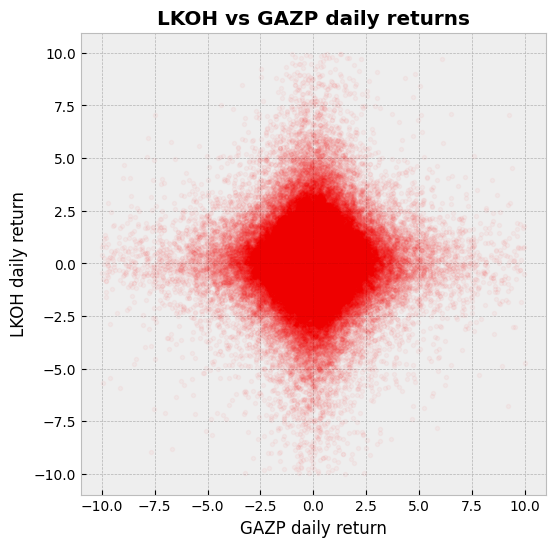

In [21]:
idx = (return_simulations['GAZP'] > -10) & (return_simulations['GAZP'] < 10)
idx = idx & (return_simulations['LKOH'] > -10) & (return_simulations['LKOH'] < 10)

x = return_simulations.loc[idx, 'GAZP']
y = return_simulations.loc[idx, 'LKOH']

fig = plt.figure()
fig.set_size_inches(6,6)

plt.plot(x, y, "r.", alpha=0.03)
plt.xlabel("GAZP daily return")
plt.ylabel("LKOH daily return")
plt.title("LKOH vs GAZP daily returns", weight="bold")
plt.show()

In [22]:
w = np.ones(shape=(returns.shape[1],)) / returns.shape[1]

# w = 1 / prices.iloc[0]
# w = w / w.sum()
portfolio_real_returns = np.dot(returns.values, w)

print(w)
portfolio_real_returns

[0.25 0.25 0.25 0.25]


array([-0.33451682, -0.89670808,  1.09255656, ..., -0.01370356,
        0.40711171, -1.01299265])

C:\Users\arzay\AppData\Local\Temp\ipykernel_11128\3139777703.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(portfolio_real_returns, hist=True, kde=False,


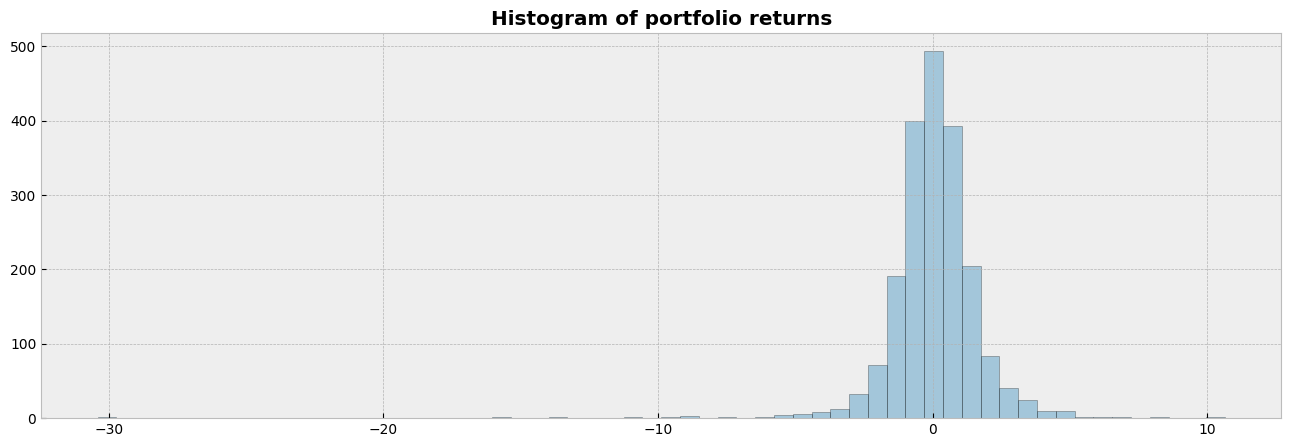

In [23]:
fig = plt.figure(figsize=(16, 5))

sns.distplot(portfolio_real_returns, hist=True, kde=False, 
             bins=60,
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

plt.title("Histogram of portfolio returns", weight="bold")

plt.show()

## Произведение одномерных распределений

Попробуем смоделировать доходности каждого актива отделььно и затем перейти к доходности портфеля с равномерными весами

In [24]:
import scipy.stats as ss

In [25]:
n_samples = 10 ** 4

return_simulations = {}

# для каждой акции оцениваем одномерное распределение, а потом сэмплируем из него новые псевдо-наблюдения
for col in returns.columns:
    t_df, t_mean, t_sigma = ss.t.fit(returns[col])
    return_simulations[col] = ss.t.rvs(t_df, loc=t_mean, scale=t_sigma, size=n_samples, random_state=42)
    
return_simulations = pd.DataFrame(return_simulations)

return_simulations.shape

(10000, 4)

C:\Users\arzay\AppData\Local\Temp\ipykernel_11128\84798434.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(portfolio_real_returns, hist=True, kde=True,
C:\Users\arzay\AppData\Local\Temp\ipykernel_11128\84798434.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(portfolio_simulated_returns,

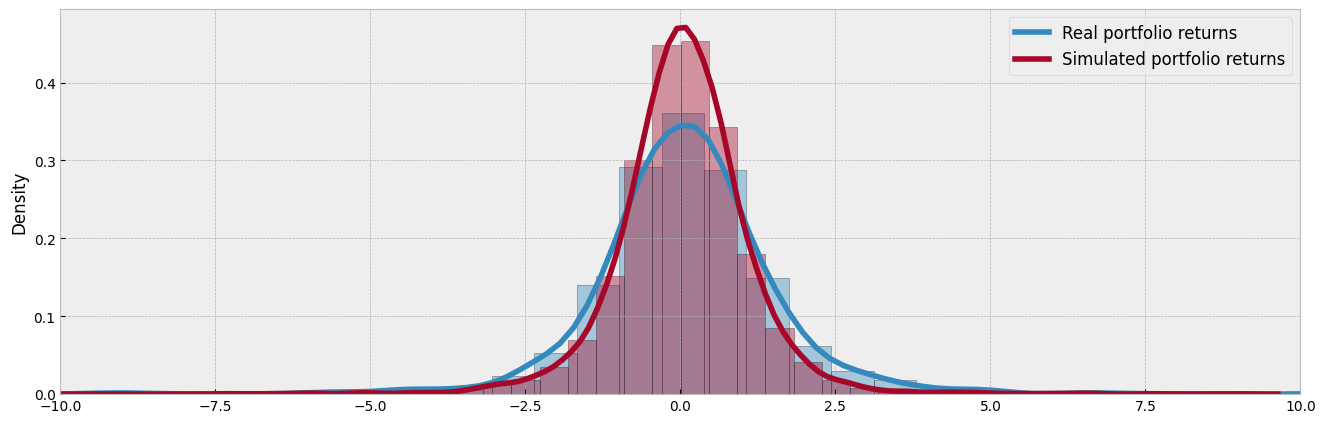

In [26]:
portfolio_simulated_returns = np.dot(return_simulations.values, w)

fig = plt.figure(figsize=(16, 5))

sns.distplot(portfolio_real_returns, hist=True, kde=True, 
             bins=60,
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

sns.distplot(portfolio_simulated_returns, hist=True, kde=True, 
             bins=60,
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

plt.xlim((-10, 10))

plt.legend(['Real portfolio returns',
            'Simulated portfolio returns'], fontsize=12)
plt.show()

Однако здесь никак не учитываются корреляции между активами.

## Многомерные распределения

Один из способов это сделать -- использовать многомерные распределения, например, многомерное нормальное распределение

In [27]:
n_samples = 10 ** 5

# оцениваем параметры нормального распределения распределение
mean = np.mean(returns.values, axis=0)
cov = np.cov(returns.values, rowvar=False)

# а потом сэмплируем из него новые псевдо-наблюдения
return_simulations = scipy.stats.multivariate_normal.rvs(mean=mean, cov=cov, size=n_samples, random_state=42)

return_simulations = pd.DataFrame(return_simulations, columns=returns.columns)

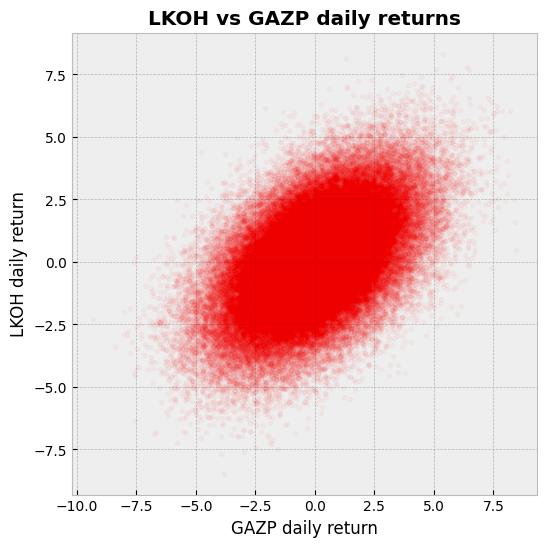

In [28]:
idx = (return_simulations['GAZP'] > -10) & (return_simulations['GAZP'] < 10)
idx = idx & (return_simulations['LKOH'] > -10) & (return_simulations['LKOH'] < 10)

x = return_simulations.loc[idx, 'GAZP']
y = return_simulations.loc[idx, 'LKOH']

fig = plt.figure()
fig.set_size_inches(6,6)

plt.plot(x, y, "r.", alpha=0.03)
plt.xlabel("GAZP daily return")
plt.ylabel("LKOH daily return")
plt.title("LKOH vs GAZP daily returns", weight="bold")
plt.show()

Посчитаем VaR для портфеля с одинаковыми весами

In [29]:
w = np.ones(shape=(returns.shape[1],)) / 3
w

array([0.33333333, 0.33333333, 0.33333333, 0.33333333])

In [30]:
alpha = 0.05

In [31]:
# умножаем матрицу псевдо-наблюдений на вектор весов и получаем псевдо-наблюдения доходностей портфеля

portfolio_real_returns = np.dot(returns.values, w)
portfolio_simulated_returns = np.dot(return_simulations.values, w)

print(np.quantile(portfolio_real_returns, alpha))
print(np.quantile(portfolio_simulated_returns, alpha))

-2.8134483620707202
-3.679469527680326


Эмпирическая квантиль и квантиль многомерного нормального распределения похожи. Посмотрим на гистограмму распределения доходностей портфеля

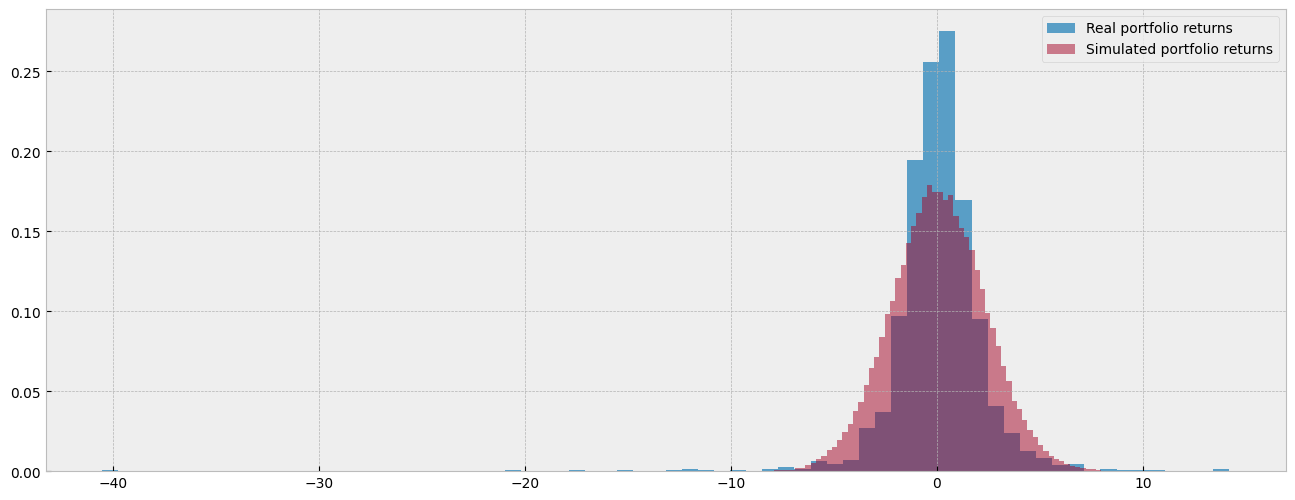

In [32]:
fig = plt.figure()
fig.set_size_inches(16,6)

plt.hist(portfolio_real_returns, bins=70, density=True, alpha=0.8, label='Real portfolio returns')
plt.hist(portfolio_simulated_returns, bins=70, density=True, alpha=0.5, label='Simulated portfolio returns')
plt.legend(loc='upper right')

Распределения сильно отличаются.

## Копулы

[Документация](https://copulae.readthedocs.io/en/latest/getting-started.html)

In [33]:
from copulae import NormalCopula, GaussianCopula, StudentCopula

Сначала моделируем частные распределения активов, например, с помощью распределения Стьюдента

In [34]:
cdfs = returns.copy()
distribution_params = {}

for col in cdfs.columns:
    t_df, t_mean, t_sigma = scipy.stats.t.fit(cdfs[col])
    distribution_params[col] = (t_df, t_mean, t_sigma)
    cdfs[col] = scipy.stats.t.cdf(cdfs[col], df=t_df, loc=t_mean, scale=t_sigma)

In [35]:
cdfs

,GAZP,SBER,LKOH,ROSN
datetime,,,,
2016-03-14,0.267282,0.473635,0.354324,0.431309
2016-03-15,0.352247,0.062886,0.348461,0.441270
2016-03-16,0.879361,0.620080,0.913113,0.553689
2016-03-17,0.898961,0.912236,0.880036,0.946155
2016-03-18,0.937784,0.933963,0.919402,0.901333
...,...,...,...,...
2024-03-06,0.645339,0.406841,0.406279,0.466082
2024-03-07,0.353210,0.719507,0.603426,0.699754
2024-03-11,0.431426,0.414813,0.648463,0.430025


In [36]:
returns

,GAZP,SBER,LKOH,ROSN
datetime,,,,
2016-03-14,-0.762301,0.000000,-0.393406,-0.182361
2016-03-15,-0.460894,-2.562694,-0.413767,-0.149477
2016-03-16,1.550442,0.507233,2.096317,0.216234
2016-03-17,1.740933,2.308411,1.738809,2.705394
2016-03-18,2.295104,2.676532,2.181818,1.987718
...,...,...,...,...
2024-03-06,0.416201,-0.231233,-0.220015,-0.068312
2024-03-07,-0.457779,0.903564,0.400909,0.734854
2024-03-11,-0.217513,-0.203063,0.552376,-0.186615


In [37]:
distribution_params

{'GAZP': (np.float64(2.70192842101475),
  np.float64(-0.018444931465658544),
  np.float64(1.0491269439339774)),
 'SBER': (np.float64(2.902814481391083),
  np.float64(0.08956807129615725),
  np.float64(1.243899087147875)),
 'LKOH': (np.float64(3.007685269551456),
  np.float64(0.07465715237205103),
  np.float64(1.13903367727965)),
 'ROSN': (np.float64(3.148744450219846),
  np.float64(0.04166347065124177),
  np.float64(1.1940129143166214))}

Посмотрим как выглядят доходности и распределение их квантилей

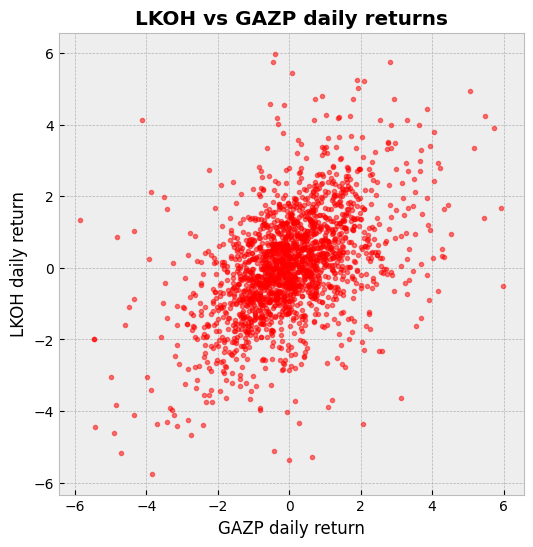

In [38]:
idx = (returns['GAZP'] > -6) & (returns['GAZP'] < 6)
idx = idx & (returns['LKOH'] > -6) & (returns['LKOH'] < 6)

x = returns.loc[idx, 'GAZP']
y = returns.loc[idx, 'LKOH']

fig = plt.figure()
fig.set_size_inches(6,6)

plt.plot(x, y, "r.", alpha=0.5)
plt.xlabel("GAZP daily return")
plt.ylabel("LKOH daily return")
plt.title("LKOH vs GAZP daily returns", weight="bold")
plt.show()

Распределение их квантилей

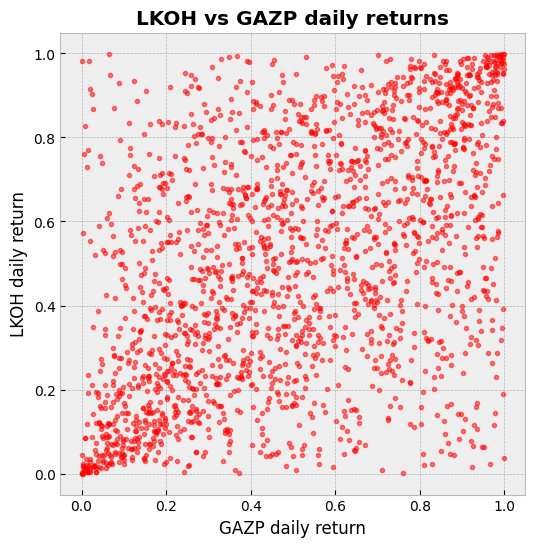

In [39]:
x = cdfs['GAZP']
y = cdfs['LKOH']

fig = plt.figure()
fig.set_size_inches(6,6)

plt.plot(x, y, "r.", alpha=0.5)
plt.xlabel("GAZP daily return")
plt.ylabel("LKOH daily return")
plt.title("LKOH vs GAZP daily returns", weight="bold")
plt.show()

Равномерное заполнение единичного квадрата характерно для независимых величин. Скопление точек в углах нарушает эту равномерность и служит визуальным подтверждением сильной корреляционной связи между активами(особенно в хваостах распределения)

In [40]:
returns.head()

,GAZP,SBER,LKOH,ROSN
datetime,,,,
2016-03-14,-0.762301,0.000000,-0.393406,-0.182361
2016-03-15,-0.460894,-2.562694,-0.413767,-0.149477
2016-03-16,1.550442,0.507233,2.096317,0.216234
2016-03-17,1.740933,2.308411,1.738809,2.705394
2016-03-18,2.295104,2.676532,2.181818,1.987718


In [41]:
cdfs.head()

,GAZP,SBER,LKOH,ROSN
datetime,,,,
2016-03-14,0.267282,0.473635,0.354324,0.431309
2016-03-15,0.352247,0.062886,0.348461,0.441270
2016-03-16,0.879361,0.620080,0.913113,0.553689
2016-03-17,0.898961,0.912236,0.880036,0.946155
2016-03-18,0.937784,0.933963,0.919402,0.901333


Оценим Нормальную копулу и посмотрим на ее описание

In [42]:
cop = NormalCopula(dim=4)
cop.fit(cdfs)

              GAZP         SBER         LKOH         ROSN
count  1999.000000  1999.000000  1999.000000  1999.000000
mean      0.500000     0.500000     0.500000     0.500000
std       0.288603     0.288603     0.288603     0.288603
min       0.000500     0.000500     0.000500     0.000500
25%       0.250250     0.250250     0.250250     0.250250
50%       0.500000     0.500000     0.500000     0.500000
75%       0.749750     0.749750     0.749750     0.749750
max       0.999500     0.999500     0.999500     0.999500


In [43]:
cop.summary()

1.000000,0.543117,0.520189,0.528844
0.543117,1.000000,0.478979,0.504241
0.520189,0.478979,1.000000,0.615276
0.528844,0.504241,0.615276,1.000000


Теперь мы можем сэмплировать частные квантили с помощью оцененной копулы, и можем построить их распределение

In [44]:
n_samples = 10 ** 5

copula_simulations = cop.random(n_samples, seed=42)

copula_simulations = pd.DataFrame(copula_simulations, columns=cdfs.columns)

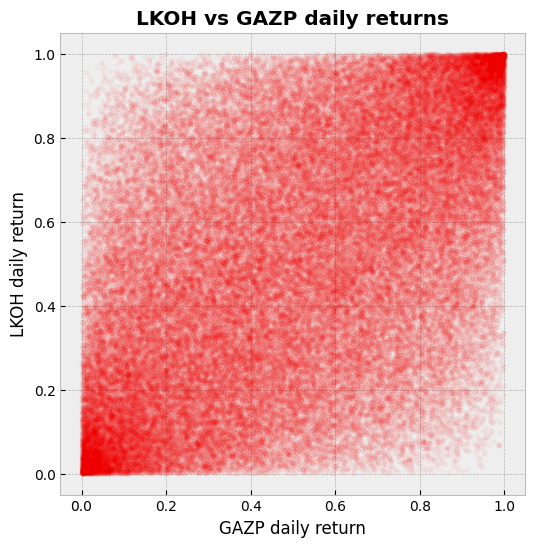

In [45]:
x = copula_simulations['GAZP']
y = copula_simulations['LKOH']

fig = plt.figure()
fig.set_size_inches(6,6)

plt.plot(x, y, "r.", alpha=0.03)
plt.xlabel("GAZP daily return")
plt.ylabel("LKOH daily return")
plt.title("LKOH vs GAZP daily returns", weight="bold")
plt.show()

Теперь вернемся от квантилей к доходностям с помощью inverse CDF и посмотрим на распределение сэмплов

In [46]:
return_simulations = copula_simulations.copy()

for col in cdfs.columns:
    t_df, t_mean, t_sigma = distribution_params[col]
    return_simulations[col] = scipy.stats.t.ppf(copula_simulations[col], df=t_df, loc=t_mean, scale=t_sigma)

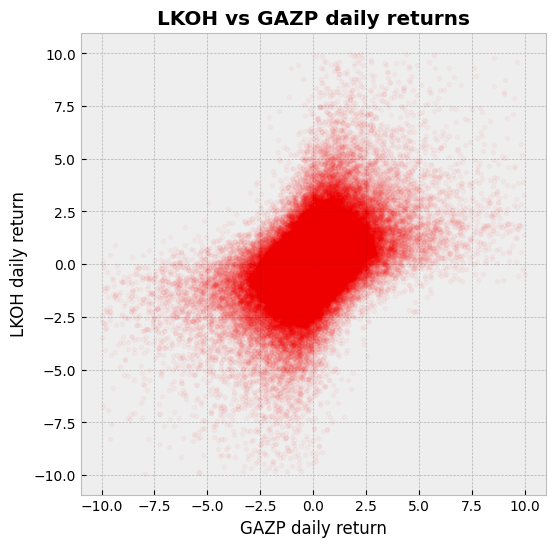

In [47]:
idx = (return_simulations['GAZP'] > -10) & (return_simulations['GAZP'] < 10)
idx = idx & (return_simulations['LKOH'] > -10) & (return_simulations['LKOH'] < 10)

x = return_simulations.loc[idx, 'GAZP']
y = return_simulations.loc[idx, 'LKOH']

fig = plt.figure()
fig.set_size_inches(6,6)

# fft_axes = fig.add_subplot(212)

plt.plot(x, y, "r.", alpha=0.03)
plt.xlabel("GAZP daily return")
plt.ylabel("LKOH daily return")
plt.title("LKOH vs GAZP daily returns", weight="bold")
plt.show()

Зависимость нелинейная. Посчитаем квантиль в данном случае, а затем посмотрим на гистограммы

In [48]:
portfolio_real_returns = np.dot(returns.values, w)
portfolio_simulated_returns = np.dot(return_simulations.values, w)

print(np.quantile(portfolio_real_returns, alpha))
print(np.quantile(portfolio_simulated_returns, alpha))

-2.8134483620707202
-3.022794148393094


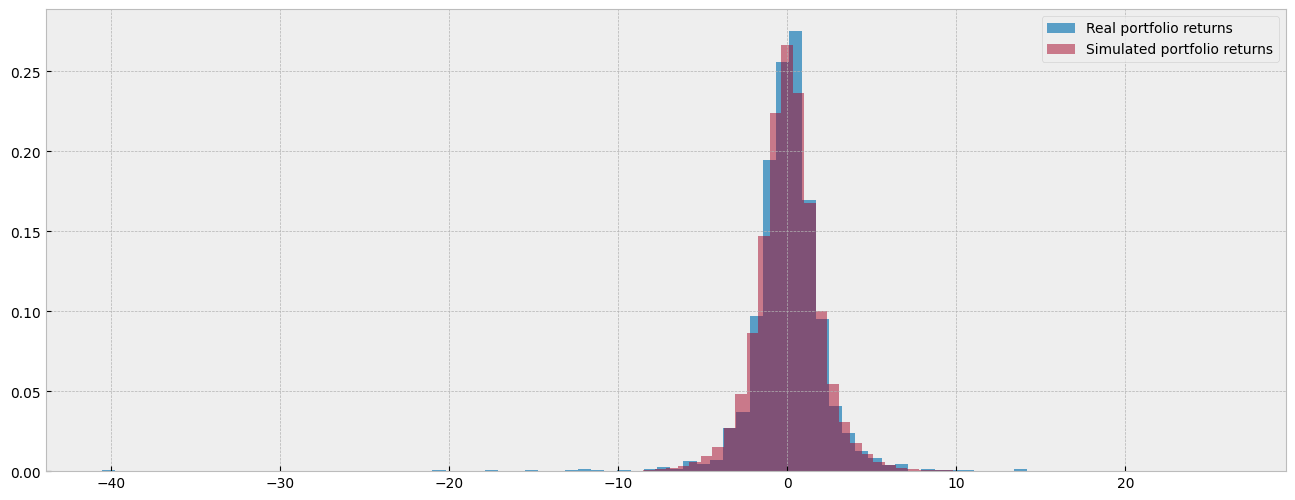

In [49]:
fig = plt.figure()
fig.set_size_inches(16,6)

plt.hist(portfolio_real_returns, bins=70, density=True, alpha=0.8, label='Real portfolio returns')
plt.hist(portfolio_simulated_returns[idx], bins=70, density=True, alpha=0.5, label='Simulated portfolio returns')
plt.legend(loc='upper right')
plt.show()

Выглядит лучше! Но мы и на этом не остановимся.


**Во-вервых**, можно использовать другие копулы и другие частные распределения

In [50]:
from copulae import ClaytonCopula, FrankCopula, GumbelCopula

In [51]:
univariate_dist = 'gennorm' # gennorm
cop = ClaytonCopula(dim=cdfs.shape[1])
n_samples = 10 ** 5

cdfs = returns.copy()
distribution_params = {}

for col in cdfs.columns:
    if univariate_dist == 't':
        t_df, t_mean, t_sigma = scipy.stats.t.fit(cdfs[col])
        distribution_params[col] = (t_df, t_mean, t_sigma)
        cdfs[col] = scipy.stats.t.cdf(cdfs[col], df=t_df, loc=t_mean, scale=t_sigma)
    else:
        beta, loc, scale = scipy.stats.gennorm.fit(cdfs[col])
        distribution_params[col] = (beta, loc, scale)
        cdfs[col] = scipy.stats.gennorm.cdf(cdfs[col], beta, loc, scale)

cop.fit(cdfs)

copula_simulations = cop.random(n_samples, seed=42)
copula_simulations = pd.DataFrame(copula_simulations, columns=cdfs.columns)

return_simulations = copula_simulations.copy()

for col in cdfs.columns:
    if univariate_dist == 't':
        t_df, t_mean, t_sigma = distribution_params[col]
        return_simulations[col] = scipy.stats.t.ppf(copula_simulations[col], df=t_df, loc=t_mean, scale=t_sigma)
    else:
        beta, loc, scale = distribution_params[col]
        return_simulations[col] = scipy.stats.gennorm.ppf(copula_simulations[col], beta, loc, scale)

              GAZP         SBER         LKOH         ROSN
count  1999.000000  1999.000000  1999.000000  1999.000000
mean      0.500000     0.500000     0.500000     0.500000
std       0.288603     0.288603     0.288603     0.288603
min       0.000500     0.000500     0.000500     0.000500
25%       0.250250     0.250250     0.250250     0.250250
50%       0.500000     0.500000     0.500000     0.500000
75%       0.749750     0.749750     0.749750     0.749750
max       0.999500     0.999500     0.999500     0.999500


In [52]:
portfolio_real_returns = np.dot(returns.values, w)
portfolio_simulated_returns = np.dot(return_simulations.values, w)

print(np.quantile(portfolio_real_returns, alpha))
print(np.quantile(portfolio_simulated_returns, alpha))

-2.8134483620707202
-3.349287235004913


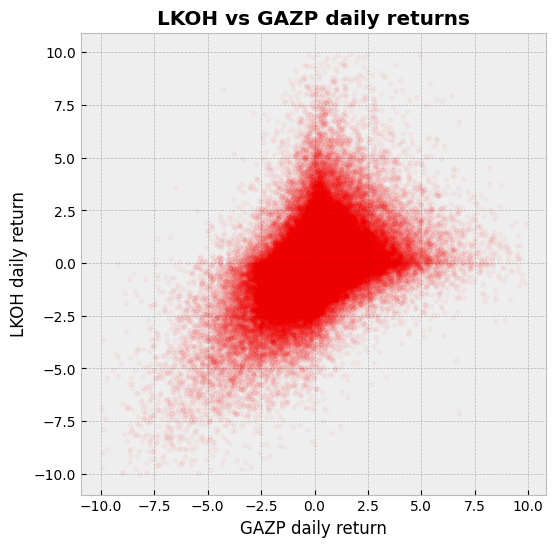

In [53]:
idx = (return_simulations['GAZP'] > -10) & (return_simulations['GAZP'] < 10)
idx = idx & (return_simulations['LKOH'] > -10) & (return_simulations['LKOH'] < 10)

x = return_simulations.loc[idx, 'LKOH']
y = return_simulations.loc[idx, 'GAZP']

fig = plt.figure()
fig.set_size_inches(6,6)

# fft_axes = fig.add_subplot(212)

plt.plot(x, y, "r.", alpha=0.03)
plt.xlabel("GAZP daily return")
plt.ylabel("LKOH daily return")
plt.title("LKOH vs GAZP daily returns", weight="bold")
plt.show()

Получилась другая зависимость

**Во-вторых**, можно использовать ARMA-GARCH для учета временной структуры доходностей

Для удобства напишем нужные нам функции

In [54]:
from arch import arch_model 

In [55]:
ret = returns.dropna()
dist = 'skewstudent'

# def get_garch_residuals(ret, dist):
def get_garch_residuals(ret, dist, arch_params=[1,0,1], lags=1):

    scaling_const = 10.0 / ret.std()

    # объявляем GARCH модель
    am = arch_model(ret * scaling_const,
                    mean='HARX', lags=lags, # mean = Constant, ARX, HARX + the number of lags
                    vol='Garch', p=arch_params[0], o=arch_params[1], q=arch_params[2], # vol = Garch, EGARCH, HARCH + the number of lags
                    dist=dist) # dist = Normal, t, skewstudent, ged

    # фитим модель на данных
    res = am.fit(update_freq=0, disp='off')

    # сохраняем ее распределение
    if dist == 'Normal':
        cdf = am.distribution.cdf(res.resid.dropna())
    elif dist == 't' or dist == 'ged':
        cdf = am.distribution.cdf(res.resid.dropna(), res.params[-1:])
    elif dist == 'skewstudent':
        cdf = am.distribution.cdf(res.resid, res.params[-2:])

    return cdf, am, res, scaling_const


def make_garch_forecast(copula_simulation, dist, garch_object, garch_model, scaling_const):

    # делаем прогноз среднего и дисперсии
    forecasts = garch_object.forecast(horizon=1, reindex=False)

    cond_mean = float(forecasts.mean.iloc[-1])
    cond_var = float(forecasts.variance.iloc[-1])

    # получаем из сэплов квантили сэмплы доходностей
    if dist == 'Normal':
        q = garch_model.distribution.ppf(copula_simulation)
    elif dist == 't' or dist == 'ged':
        q = garch_model.distribution.ppf(copula_simulation, garch_object.params[-1:])
    elif dist == 'skewstudent':
        q = garch_model.distribution.ppf(copula_simulation, garch_object.params[-2:])

    # и по формуле считаем ВаР
    return (cond_mean + np.sqrt(cond_var) * q) / scaling_const

In [56]:
def make_copula_simulation(returns, copula_func, n_samples, univariate_dist, dist='skewstudent', arch_params=[1,0,1], lags=1):

    # объявляем копулу
    cop = copula_func(dim=returns.shape[1])

    cdfs = returns.copy()
    distribution_params = {}

    # моделируем частные распределения для каждой акции
    for col in cdfs.columns:
        if univariate_dist == 't':
            t_df, t_mean, t_sigma = scipy.stats.t.fit(returns[col])
            distribution_params[col] = (t_df, t_mean, t_sigma)
            cdfs[col] = scipy.stats.t.cdf(cdfs[col], df=t_df, loc=t_mean, scale=t_sigma)

        elif univariate_dist == 'gennorm':
            beta, loc, scale = scipy.stats.gennorm.fit(returns[col])
            distribution_params[col] = (beta, loc, scale)
            cdfs[col] = scipy.stats.gennorm.cdf(cdfs[col], beta, loc, scale)

        elif univariate_dist == 'garch':
            cdf, am, res, scaling_const= get_garch_residuals(returns[col], dist, arch_params=arch_params, lags=lags)
            distribution_params[col] = (am, res)
            cdfs[col] = np.nan_to_num(cdf)


    # фитим копулу
    cop.fit(cdfs)

    # делаем сэмплирование квантилей из совместного распределения копулы
    copula_simulations = cop.random(n_samples, seed=42)
    copula_simulations = pd.DataFrame(copula_simulations, columns=cdfs.columns)

    return_simulations = copula_simulations.copy()

    # трансформируем квантили в доходности с помощью частных функций распределений из первого шага
    for col in cdfs.columns:
        if univariate_dist == 't':
            t_df, t_mean, t_sigma = distribution_params[col]
            return_simulations[col] = scipy.stats.t.ppf(copula_simulations[col], df=t_df, loc=t_mean, scale=t_sigma)

        elif univariate_dist == 'gennorm':
            beta, loc, scale = distribution_params[col]
            return_simulations[col] = scipy.stats.gennorm.ppf(copula_simulations[col], beta, loc, scale)

        elif univariate_dist == 'garch':
            am, res = distribution_params[col]
            return_simulations[col] = make_garch_forecast(copula_simulations[col], dist, res, am, scaling_const)
            
    # возвращаем матрицу сэмплированных доходностей
    return return_simulations

*Пункт 1) о дополнении функций для смены параметров количества лагов в модели arch выполнен*

Посмотрим, как можно использовать все эти замечательные функции

In [57]:
cdf, am, res, scaling_const =  get_garch_residuals(returns[col], dist)

In [58]:
return_simulations = make_copula_simulation(returns, ClaytonCopula, n_samples=10**5, univariate_dist='garch')

              GAZP         SBER         LKOH         ROSN
count  1999.000000  1999.000000  1999.000000  1999.000000
mean      0.500000     0.500000     0.500000     0.500000
std       0.288603     0.288603     0.288603     0.288603
min       0.000500     0.000500     0.000500     0.000500
25%       0.250250     0.250250     0.250250     0.250250
50%       0.500000     0.500000     0.500000     0.500000
75%       0.749750     0.749750     0.749750     0.749750
max       0.999500     0.999500     0.999500     0.999500


C:\Users\arzay\AppData\Local\Temp\ipykernel_11128\957354325.py:34: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  cond_mean = float(forecasts.mean.iloc[-1])
C:\Users\arzay\AppData\Local\Temp\ipykernel_11128\957354325.py:35: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  cond_var = float(forecasts.variance.iloc[-1])
C:\Users\arzay\AppData\Local\Temp\ipykernel_11128\957354325.py:34: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  cond_mean = float(forecasts.mean.iloc[-1])
C:\Users\arzay\AppData\Local\Temp\ipykernel_11128\957354325.py:35: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  cond_var = float(for

In [59]:
alpha = 0.05

w = np.ones(shape=(returns.shape[1],)) / 3

portfolio_real_returns = np.dot(returns.values, w)
portfolio_simulated_returns = np.dot(return_simulations.values, w)

print(np.quantile(portfolio_real_returns, alpha))
print(np.quantile(portfolio_simulated_returns, alpha))

-2.8134483620707202
-1.9734154265191053


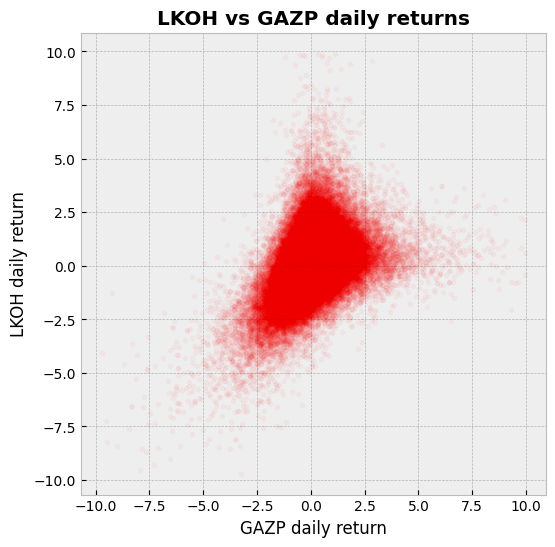

In [60]:
idx = (return_simulations['GAZP'] > -10) & (return_simulations['GAZP'] < 10)
idx = idx & (return_simulations['LKOH'] > -10) & (return_simulations['LKOH'] < 10)

x = return_simulations.loc[idx, 'GAZP']
y = return_simulations.loc[idx, 'LKOH']

fig = plt.figure()
fig.set_size_inches(6,6)

# fft_axes = fig.add_subplot(212)

plt.plot(x, y, "r.", alpha=0.03)
plt.xlabel("GAZP daily return")
plt.ylabel("LKOH daily return")
plt.title("LKOH vs GAZP daily returns", weight="bold")
plt.show()

Перейдем к бэктесту -- напишем еще пару функций для моделирования совместного распределения доходностей

In [61]:
def make_dummy_student_simulations(returns, n_samples):
    
    return_simulations = {}

    for col in returns.columns:
        t_df, t_mean, t_sigma = scipy.stats.t.fit(returns[col])
        return_simulations[col] = scipy.stats.t.rvs(t_df, loc=t_mean, scale=t_sigma, size=n_samples, random_state=42)

    return_simulations = pd.DataFrame(return_simulations)

    return return_simulations


def make_mult_normal_simulations(returns, n_samples):

    mean = np.mean(returns.values, axis=0)
    cov = np.cov(returns.values, rowvar=False)

    return_simulations = scipy.stats.multivariate_normal.rvs(mean=mean, cov=cov, size=n_samples, random_state=42)

    return_simulations = pd.DataFrame(return_simulations, columns=returns.columns)

    return return_simulations


Наконец, перейдем к самому бэктесту!

In [63]:
%%capture
alpha = 0.05

w = np.ones(shape=(returns.shape[1],)) / 5

# определяем параметры бэктеста
T = len(ret)
T_start = 100
estimation_window = 500
testing_window = T - estimation_window

# инициализация списков
VaR_curve_HS = []
VaR_curve_student = []
VaR_curve_multivariate_normal = []

VaR_curve_copula_t = []
VaR_curve_copula_gaussian = []
VaR_curve_copula_clayton = []
VaR_curve_copula_gumbel = []
VaR_curve_copula_frank = []
VaR_curve_copula_garch = []

# в цикле проходимся по всем дням в выборке
for t in range(estimation_window+T_start, T):
    
    # фиксируем часть выборки
    current_estimation_sample = returns[t-estimation_window:t]
    
    # различными способами оцениваем ВаР и сохраняем значения
    protfolio = np.dot(current_estimation_sample.values, w)

    VaR_curve_HS.append(np.quantile(protfolio, alpha))
    
    student_simulation = make_dummy_student_simulations(current_estimation_sample, 10**4)
    VaR_curve_student.append(np.quantile(np.dot(student_simulation.values, w), alpha))
    
    multivariate_normal_simulation = make_mult_normal_simulations(current_estimation_sample, 10**4)
    VaR_curve_multivariate_normal.append(np.quantile(np.dot(multivariate_normal_simulation.values, w), alpha))

    # Student Copula 
    copula_t_simulation = make_copula_simulation(current_estimation_sample, StudentCopula, n_samples=10**4, univariate_dist='t')
    VaR_curve_copula_t.append(np.quantile(np.dot(copula_t_simulation.values, w), alpha))

    #Gaussian Copula 
    copula_gaussian_simulation = make_copula_simulation(current_estimation_sample, GaussianCopula, n_samples=10**4, univariate_dist='gennorm')
    VaR_curve_copula_gaussian.append(np.quantile(np.dot(copula_gaussian_simulation.values, w), alpha))

    # Clayton Copula    
    copula_clayton_simulation = make_copula_simulation(current_estimation_sample, ClaytonCopula, n_samples=10**4, univariate_dist='t')
    VaR_curve_copula_clayton.append(np.quantile(np.dot(copula_clayton_simulation.values, w), alpha))

    # Gumbel Copula     
    copula_gumbel_simulation = make_copula_simulation(current_estimation_sample, GumbelCopula, n_samples=10**4, univariate_dist='t')
    VaR_curve_copula_gumbel.append(np.quantile(np.dot(copula_gumbel_simulation.values, w), alpha))

    # Frank Copula
    copula_frank_simulation = make_copula_simulation(current_estimation_sample, FrankCopula, n_samples=10**4, univariate_dist='t')
    VaR_curve_copula_frank.append(np.quantile(np.dot(copula_frank_simulation.values, w), alpha))

    # GARCH Copula     
    copula_garch_simulation = make_copula_simulation(current_estimation_sample, ClaytonCopula,
                                                     n_samples=10**4, univariate_dist='garch')
    VaR_curve_copula_garch.append(np.quantile(np.dot(copula_garch_simulation.values, w), alpha))
    
    
idx = ret[estimation_window+T_start:].index
VaR_curve_HS = pd.Series(VaR_curve_HS, index=idx)
VaR_curve_student = pd.Series(VaR_curve_student, index=idx)
VaR_curve_multivariate_normal = pd.Series(VaR_curve_multivariate_normal, index=idx)

VaR_curve_copula_t = pd.Series(VaR_curve_copula_t, index=idx)
VaR_curve_copula_gaussian = pd.Series(VaR_curve_copula_gaussian, index=idx)
VaR_curve_copula_clayton = pd.Series(VaR_curve_copula_clayton, index=idx)
VaR_curve_copula_gumbel = pd.Series(VaR_curve_copula_gumbel, index=idx)
VaR_curve_copula_frank = pd.Series(VaR_curve_copula_frank, index=idx)
VaR_curve_copula_garch = pd.Series(VaR_curve_copula_garch, index=idx)

portfolio = pd.Series(np.dot(returns[estimation_window+T_start:].values, w), index=idx)

Посмотрим на график доходностей и на VaR кривые

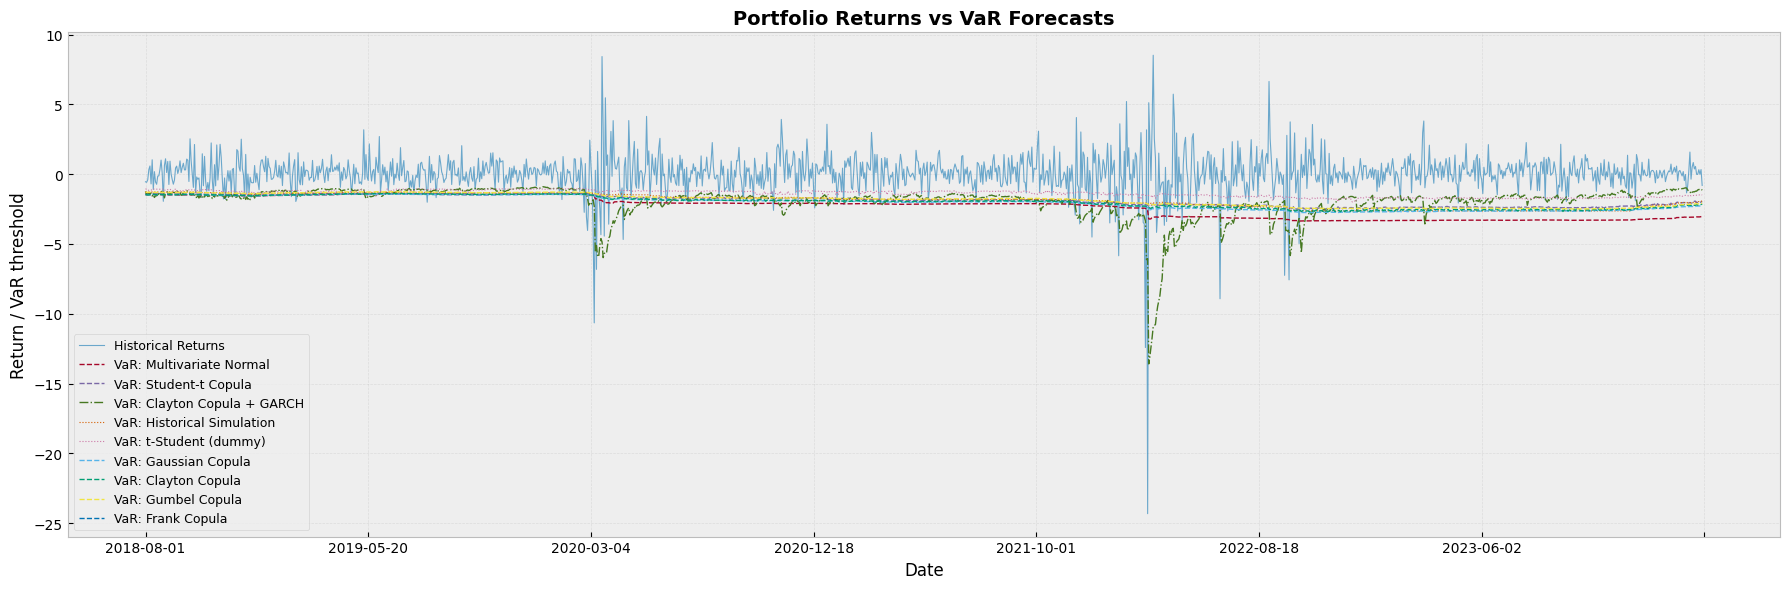

In [69]:
fig = plt.figure()
fig.set_size_inches(18, 6)

# Фактические доходности портфеля
portfolio.plot(label='Historical Returns', linewidth=0.8, alpha=0.7)

# VaR-кривые (отрицательные значения = пороги потерь)
VaR_curve_multivariate_normal.plot(label='VaR: Multivariate Normal', linestyle='--', linewidth=1)
VaR_curve_copula_t.plot(label='VaR: Student-t Copula', linestyle='--', linewidth=1)  # ← исправлено: была t-Copula, а не Clayton
VaR_curve_copula_garch.plot(label='VaR: Clayton Copula + GARCH', linestyle='-.', linewidth=1)

VaR_curve_HS.plot(label='VaR: Historical Simulation', linestyle=':', linewidth=0.8)
VaR_curve_student.plot(label='VaR: t-Student (dummy)', linestyle=':', linewidth=0.8)
VaR_curve_copula_gaussian.plot(label='VaR: Gaussian Copula', linestyle='--', linewidth=1)
VaR_curve_copula_clayton.plot(label='VaR: Clayton Copula', linestyle='--', linewidth=1)
VaR_curve_copula_gumbel.plot(label='VaR: Gumbel Copula', linestyle='--', linewidth=1)
VaR_curve_copula_frank.plot(label='VaR: Frank Copula', linestyle='--', linewidth=1)

plt.title("Portfolio Returns vs VaR Forecasts", weight="bold", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Return / VaR threshold")
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left', fontsize=9)  # ← легенда теперь точно соответствует линиям
plt.tight_layout()
plt.show()

Статические копулы дают более консервативные оценки VaR (линии ниже), чем многомерное нормальное распределение. Модель Clayton + GARCH менее консервативна (линия выше, ближе к Normal), что позволяет эффективнее использовать капитал без избыточных резервов

In [67]:
# fig = plt.figure()
# fig.set_size_inches(18,6)
# portfolio.plot()
# # VaR_curve_HS.plot()
# # VaR_curve_student.plot()
# VaR_curve_multivariate_normal.plot()
# VaR_curve_copula_t.plot()
# VaR_curve_copula_garch.plot()

# plt.title("Portfolio returns and VaR curves", weight="bold")

# plt.legend(['Historical Returns',
# #             'VaR via Historical Simulation',
# #             'VaR via t-Student distribution',
#             'VaR via Multivariate Normal disctribution',
#             'VaR via Clayton Copula with t-Student marginal distribution',
#            'VaR via Clayton Copula + GARCH with t-Student marginal distribution'])
# plt.show()

Проведем тесты Купика

In [70]:
kupiec_test(VaR_curve_HS, portfolio)

Количество наблюдений: 1399
Желаемый уровень пробитий: 5.0%
Уровень пробитий в модели: 5.72%

p-value теста: 0.228

При уровне значимости 10% гипотеза гипотеза о
том, что эмпирическая и модельная частоты превышений фактическими
убытками границы VaR равны, НЕ ОТВЕРГАЕТСЯ


In [71]:
kupiec_test(VaR_curve_student, portfolio)

Количество наблюдений: 1399
Желаемый уровень пробитий: 5.0%
Уровень пробитий в модели: 9.01%

p-value теста: 0.000

При уровне значимости 10.0% гипотеза гипотеза о
том, что эмпирическая и модельная частоты превышений фактическими
убытками границы VaR равны, отвергается


In [72]:
kupiec_test(VaR_curve_multivariate_normal, portfolio)

Количество наблюдений: 1399
Желаемый уровень пробитий: 5.0%
Уровень пробитий в модели: 3.65%

p-value теста: 0.015

При уровне значимости 10.0% гипотеза гипотеза о
том, что эмпирическая и модельная частоты превышений фактическими
убытками границы VaR равны, отвергается


In [73]:
kupiec_test(VaR_curve_copula_t, portfolio)

Количество наблюдений: 1399
Желаемый уровень пробитий: 5.0%
Уровень пробитий в модели: 5.22%

p-value теста: 0.710

При уровне значимости 10% гипотеза гипотеза о
том, что эмпирическая и модельная частоты превышений фактическими
убытками границы VaR равны, НЕ ОТВЕРГАЕТСЯ


In [74]:
kupiec_test(VaR_curve_copula_garch, portfolio)

Количество наблюдений: 1399
Желаемый уровень пробитий: 5.0%
Уровень пробитий в модели: 4.79%

p-value теста: 0.716

При уровне значимости 10% гипотеза гипотеза о
том, что эмпирическая и модельная частоты превышений фактическими
убытками границы VaR равны, НЕ ОТВЕРГАЕТСЯ


In [75]:
kupiec_test(VaR_curve_copula_gaussian, portfolio)

Количество наблюдений: 1399
Желаемый уровень пробитий: 5.0%
Уровень пробитий в модели: 4.36%

p-value теста: 0.262

При уровне значимости 10% гипотеза гипотеза о
том, что эмпирическая и модельная частоты превышений фактическими
убытками границы VaR равны, НЕ ОТВЕРГАЕТСЯ


In [76]:
kupiec_test(VaR_curve_copula_clayton, portfolio)

Количество наблюдений: 1399
Желаемый уровень пробитий: 5.0%
Уровень пробитий в модели: 4.57%

p-value теста: 0.459

При уровне значимости 10% гипотеза гипотеза о
том, что эмпирическая и модельная частоты превышений фактическими
убытками границы VaR равны, НЕ ОТВЕРГАЕТСЯ


In [77]:
kupiec_test(VaR_curve_copula_gumbel, portfolio)


Количество наблюдений: 1399
Желаемый уровень пробитий: 5.0%
Уровень пробитий в модели: 5.79%

p-value теста: 0.186

При уровне значимости 10% гипотеза гипотеза о
том, что эмпирическая и модельная частоты превышений фактическими
убытками границы VaR равны, НЕ ОТВЕРГАЕТСЯ


In [78]:
kupiec_test(VaR_curve_copula_frank, portfolio)

Количество наблюдений: 1399
Желаемый уровень пробитий: 5.0%
Уровень пробитий в модели: 0.00%

p-value теста: 0.000

При уровне значимости 10.0% гипотеза гипотеза о
том, что эмпирическая и модельная частоты превышений фактическими
убытками границы VaR равны, отвергается


*Пункт 2 выполнен*

Проведен бэктест для нескольких спецификаций моделей

Наилучший результат показала модель Clayton Copula + GARCH(1,0,1):
 p-value = 0.716 (наибольший среди всех моделей)
 Фактический уровень пробитий = 4.79% (максимально близок к целевым 5%)
 Гипотеза НЕ ОТВЕРГАЕТСЯ, модель можно использовать

Student-t Copula также показала хороший результат:
 p-value = 0.710
 Уровень пробитий = 5.22%
 Гипотеза НЕ ОТВЕРГАЕТСЯ

Историческое моделирование (HS):
p-value = 0.228
Уровень пробитий = 5.72%
Гипотеза НЕ ОТВЕРГАЕТСЯ, но качество ниже копул

Отклоненные модели:
 Multivariate Normal: p-value = 0.015 (слишком консервативна, 3.65% пробитий)
 Student-t (dummy): p-value = 0.000 (слишком либеральна, 9.01% пробитий)

***ВЫВОД: Для оценки риска портфеля рекомендуется использовать Clayton Copula + GARCH(1,0,1) как наиболее адекватную спецификацию***

Как мы видим, самое большое p-value, а также самый близкий к нужному нам уровень пробоев оказался как раз-таки у Copula-GARCH модели.


----------


Теперь перейдем к финальному этапу -- получению из всего это выгоды. Напишем функцию, которая подбирает веса портфеля таким образом, чтобы минимизировать его риск (то есть Value-at-Risk)

In [80]:
from scipy.optimize import minimize

# объявляем целевую функцию, которую мы будем минимизировать (поэтому в нужных местах ставим минусы)
def calculate_objective_function(weights, returns_simulation, objective_type, alpha=0.1):
    
    portfolio_simulation = np.dot(returns_simulation.values, weights)
    
    if objective_type == 'return':
        return -np.mean(portfolio_simulation)
    
    elif objective_type == 'var':
        return -np.quantile(portfolio_simulation, alpha)
    
    elif objective_type == 'es_to_es': # Expected Success/Shortfall Ratio
        return -np.mean(portfolio_simulation[portfolio_simulation>np.quantile(portfolio_simulation, 1-alpha)]) / np.mean(
            portfolio_simulation[portfolio_simulation<np.quantile(portfolio_simulation, alpha)])
    
    
def optimize(returns_simulation, alpha=0.01, objective_type='var', init_guess=None):
        
    if init_guess is None: init_guess = np.ones(shape=(returns.shape[1],)) / returns.shape[1]
    
    # вот тут можно поставить другие ограничения, например от -1 до 1, чтобы появилась возможность шортить -- продавать какие-то акции
    bounds = ((0.0, 1.0),) * returns.shape[1]
    
    weights = minimize(calculate_objective_function, init_guess,
                       args=(returns_simulation,alpha,objective_type), method='SLSQP',
                       options={'disp': False},
                       constraints=({'type': 'eq', 'fun': lambda inputs: 1.0 - np.sum(inputs)}),
                       bounds=bounds)
    
    return weights.x

*Выполнен пункт 3 с добавлением подборов весов Expected Success/Shortfall Ratio*

Используем эту функцию, чтобы сравнить поведение трех портфелей -- с константными весами, и с весами, которые минимизируют VaR оцененный с помощью многомерного нормального распределения и Copula-GARCH

In [85]:
# real_returns
portfolio

datetime
2018-08-01   -0.549650
2018-08-02   -0.587345
2018-08-03   -0.410920
2018-08-06    0.322470
2018-08-07    0.581990
                ...   
2024-03-06   -0.020672
2024-03-07    0.316310
2024-03-11   -0.010963
2024-03-12    0.325689
2024-03-13   -0.810394
Length: 1399, dtype: float64

In [86]:
print(returns.iloc[:3].values)

[[-0.76230076  0.         -0.39340577 -0.18236074]
 [-0.46089385 -2.56269449 -0.41376716 -0.14947683]
 [ 1.55044198  0.50723276  2.09631728  0.2162342 ]]


In [105]:
%%capture
import numpy as np
import pandas as pd
from scipy.optimize import minimize

alpha = 0.05
w_equal = np.ones(shape=(returns.shape[1],)) / 5

T = len(ret)
T_start = 100
estimation_window = 500
value = 100.0

val_const = [value]
val_opt_es = [value]

def safe_es_ratio_objective(weights, sim_data, alpha=0.05):
    port_ret = sim_data @ weights
    var_l = np.quantile(port_ret, alpha)
    var_r = np.quantile(port_ret, 1 - alpha)
    
    es_left = -np.mean(port_ret[port_ret <= var_l])
    es_right = np.mean(port_ret[port_ret >= var_r])
    
    if es_left <= 1e-8 or np.isnan(es_left) or np.isnan(es_right):
        return 1e6  # Большой штраф, чтобы оптимизатор ушёл от плохих весов
        
    return -(es_right / es_left)  # Минимизируем отрицательное отношение

for t in range(estimation_window + T_start, T):
    r_today = returns.iloc[t].values / 100
    
    if np.any(np.isnan(r_today)):
        val_const.append(val_const[-1])
        val_opt_es.append(val_opt_es[-1])
        continue
        
    ret_const = np.dot(w_equal, r_today)
    val_const.append(val_const[-1] * (1 + ret_const))
    
    current_sample = returns[t-estimation_window:t]
    
    try:
        sim = make_copula_simulation(
            current_sample, 
            ClaytonCopula, 
            n_samples=5000,
            univariate_dist='garch',
            arch_params=(1, 0, 1)
        )
        
        res = minimize(
            safe_es_ratio_objective, 
            x0=w_equal, 
            args=(sim.values, alpha),
            method='SLSQP',
            bounds=[(0.01, 0.99) for _ in range(returns.shape[1])], # Веса от 1% до 99%
            constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0} # Сумма весов = 1
        )
        
        w_opt = res.x
        w_opt = w_opt / np.sum(w_opt)
        
        ret_opt = np.dot(w_opt, r_today)
        val_opt_es.append(val_opt_es[-1] * (1 + ret_opt))
        
    except Exception as e:
        val_opt_es.append(val_opt_es[-1])

val_const.pop(0)
val_opt_es.pop(0)

idx = ret[estimation_window+T_start:].index
s_const = pd.Series(val_const, index=idx)
s_opt = pd.Series(val_opt_es, index=idx)

Построим график изменения стоимости нашего портфеля

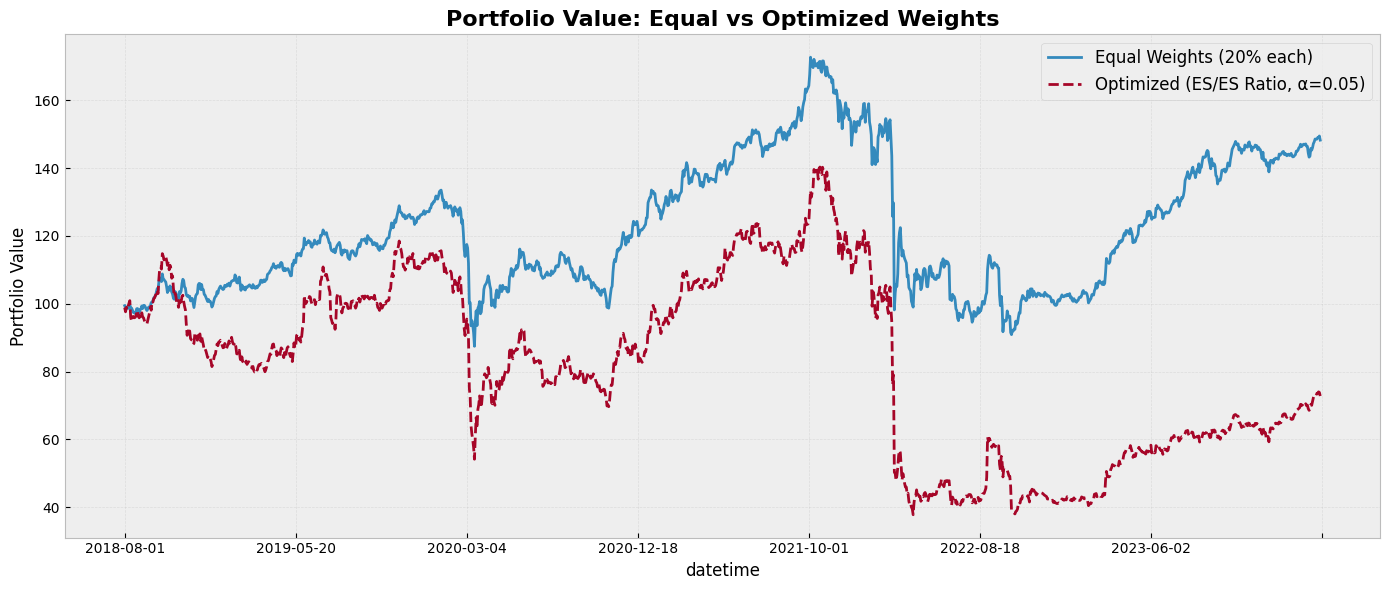

In [106]:
plt.figure(figsize=(14, 6))
s_const.plot(label='Equal Weights (20% each)', linewidth=2)
s_opt.plot(label='Optimized (ES/ES Ratio, α=0.05)', linewidth=2, linestyle='--')

plt.title('Portfolio Value: Equal vs Optimized Weights', fontsize=16, weight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylabel('Portfolio Value')
plt.tight_layout()
plt.show()

Теория нас не подвела и самой "доходной" оказалась именно модель Copula-GARCH, которая учитывает как временную структуру временного ряда, так и нелинейные зависимости между его активами


Естественно, это не самая лучшая стратегия т.к. мы даже не смотрели на потенциальную доходность активов, а только минимизировали риск.

---------

*Выполнен пункт 4*

Портфель с весами, оптимизированными по критерию Expected Success/Shortfall Ratio (альфа=0,05), в среднем уступает портфелю с равными весами (20%) на протяжении всего тестового периода

В периоды роста рынка (2020–2021, 2023–2024) оптимизированный портфель отстает, демонстрируя более низкую доходность. Это связано с консервативной природой метрики ES/ES, которая смещает веса в сторону контроля хвостовых рисков, а не максимизации общей прибыли

В кризисные периоды (март 2020, февраль 2022) оба портфеля проседают, однако оптимизированный вариант показывает более глубокие просадки и замедленное восстановление. Вероятно, это обусловлено частой перебалансировкой на скользящем окне и реакцией GARCH-компоненты на локальные всплески волатильности, что в условиях трендового рынка приводит к излишней "перестраховке"

Таким образом, стратегия равных весов оказалась более устойчивой и доходной в данном контексте, а оптимизация по ES/ES пожертвовала общей доходностью ради снижения хвостовых рисков.